In [8]:
import numpy as np
import qutip as qt
from Quantum_dot_2qubit import *
from tqdm import tqdm
import pickle
from entropy import RDM_entropy, von_neumann_entropy
from qiskit.quantum_info import Statevector, partial_trace
import random as rand
from gibbs import thermal_state
from math import sqrt
qubits=8

exact_model = Quantum_dot(J0=np.pi/1e-7,N=qubits)
analog_model = analog_QD(exact_model, h=1e5,J=1e5, DeltaE=2e8,epsilon=0.01)

# def computation_basis_state(num_qubits):
#     #retrun a list of all computational basis states for num_qubits qubits, represented as integers lists
#     basis_states = []
#     for i in range(2**num_qubits):
#         bin_str = format(i, '0' + str(num_qubits) + 'b')
#         basis_states.append([int(bit) for bit in bin_str])
#     return basis_states

# def thermal_state(temperature):
#     basis = computation_basis_state(8)
#     computation_basis = [basis[i]+basis[i] for i in range(len(basis))]
#     H=qt.Qobj(np.zeros((d,d)), dims=[[2]*N]*2)
#     for i in range(8,N):
#         H-=qt.tensor([qt.sigmaz() if j == i else qt.qeye(2) for j in range(N)])
#     # psi_T = qt.Qobj(np.zeros(d), dims=[2]*N)
#     psi_T = qt.Qobj(np.zeros((d,1)), dims=[[2]*N, [1]])
#     for A_subsys in computation_basis:
#         psi_T += qt.basis([2]*16,A_subsys)
#     # Calculate the thermal state using the Gibbs distribution
#     psi_T = (-H * temperature).expm()*psi_T

#     return psi_T.unit()

def analog_error(initial_state, analog_model : analog_QD,time):
    # Compute the error between the initial state and the analog model
    exact_states=qt.mesolve(analog_model.exact_model.H,initial_state, time).states
    analog_states=qt.mesolve(analog_model.H,initial_state, time).states
    errors = [exact_states[i]-analog_states[i] for i in range(len(time))]
    error_norms = [err.norm('l2') for err in errors]
    return error_norms

t=1e-7
U_e=[]
for i in range(4):
    U_e.append((-1j*exact_model.H*t*(0.25+0.25*i)).expm()-(-1j*analog_model.H*t*(0.25+0.25*i)).expm())
error_list=[]
entropy_list=[]
for temperature in tqdm(range(100)):
    rho_T = thermal_state((temperature)*0.008,qubits)
    error_list.append([sqrt(np.real((U.dag()*U*rho_T).tr())) for U in U_e])
    entropy_list.append(von_neumann_entropy(rho_T.full()))

100%|██████████| 100/100 [00:10<00:00,  9.12it/s]


In [9]:
bound=[]
for i in range(4):
    bound.append(t*(0.25+0.25*i)*np.linalg.norm((exact_model.H-analog_model.H).full(),'fro')/16)

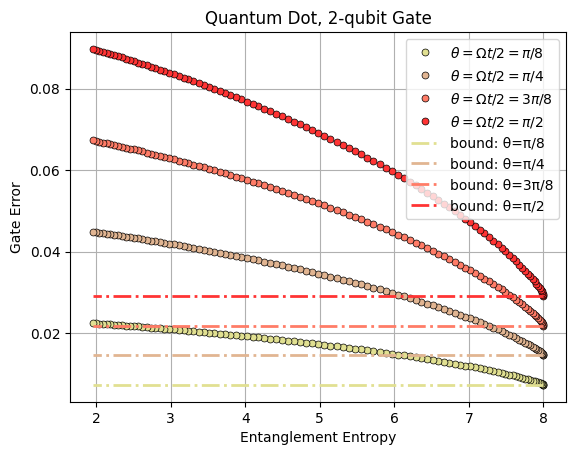

In [10]:
from scipy.optimize import curve_fit
# def error_vs_entropy(t,a,b):
#     return a*np.power(2.01-t,0.25)+b
# error_plot_list=[]
# for i in range(4):
#     error_plot_list.append(np.array(error_list)[:,i+1])
# fit_line1 = []
# popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[0], p0=[0.01, 0.01])
# fit_line1 = error_vs_entropy(np.array(entropy_list), *popt)

# fit_line2 = []
# popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[1], p0=[0.01, 0.01])
# fit_line2 = error_vs_entropy(np.array(entropy_list), *popt)

# fit_line3 = []
# popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[2], p0=[0.01, 0.01])
# fit_line3 = error_vs_entropy(np.array(entropy_list), *popt)

# fit_line4 = []
# popt, pcov = curve_fit(error_vs_entropy, entropy_list, error_plot_list[3], p0=[0.01, 0.01])
# fit_line4 = error_vs_entropy(np.array(entropy_list), *popt)

import matplotlib.pyplot as plt
plt.plot(entropy_list,np.array(error_list)[:,0],color='0.3', marker='o', markersize=5, mfc="#e1e092", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\Omega t/2=\pi/8$')
plt.plot(entropy_list,np.array(error_list)[:,1],color='0.3', marker='o', markersize=5, mfc="#e1b592", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\Omega t/2=\pi/4$')
plt.plot(entropy_list,np.array(error_list)[:,2],color='0.3', marker='o', markersize=5, mfc="#ff7c67", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\Omega t/2=3\pi/8$')
plt.plot(entropy_list,np.array(error_list)[:,3],color='0.3', marker='o', markersize=5, mfc="#ff3434", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\Omega t/2=\pi/2$')
# plt.plot(entropy_list,fit_line1,color="#82c5c7", linestyle='--', label='fit: θ=π/8',linewidth=2)
# plt.plot(entropy_list,fit_line2,color="#88be7d", linestyle='--', label='fit: θ=π/4',linewidth=2)
# plt.plot(entropy_list,fit_line3,color="#b8a978", linestyle='--', label='fit: θ=3π/8',linewidth=2)
# plt.plot(entropy_list,fit_line4,color="#be7d7d", linestyle='--', label='fit: θ=π/2',linewidth=2)
plt.plot(entropy_list,[bound[0]]*100,color='#e1e092', linestyle='-.', label='bound: θ=π/8',linewidth=2)
plt.plot(entropy_list,[bound[1]]*100,color='#e1b592', linestyle='-.', label='bound: θ=π/4',linewidth=2)
plt.plot(entropy_list,[bound[2]]*100,color='#ff7c67', linestyle='-.', label='bound: θ=3π/8',linewidth=2)
plt.plot(entropy_list,[bound[3]]*100,color="#ff3434", linestyle='-.', label='bound: θ=π/2',linewidth=2)
plt.xlabel('Entanglement Entropy')
plt.ylabel('Gate Error')
plt.title('Quantum Dot, 2-qubit Gate')
plt.legend(loc=1)
plt.grid()
plt.savefig('./Figures/QD_2qubits.pdf',bbox_inches='tight',dpi=600)
plt.show()